<a href="https://colab.research.google.com/github/Raymondycp/Analytic_BroadbandCompany_CustomersChurn_RFC/blob/main/%5BAnalytic%5DBroadbandCompany_CustomersChurn_RFC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## EDA

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
# 1: Exploring Data
df = pd.read_csv('broadband.csv')
df.head() # broadband ：0-Churn，1-Stay

,CUST_ID,GENDER,AGE,TENURE,CHANNEL,AUTOPAY,ARPB_3M,CALL_PARTY_CNT,DAY_MOU,AFTERNOON_MOU,NIGHT_MOU,AVG_CALL_LENGTH,BROADBAND
0,63,1,34,27,2,0,203,0,0.0,0.0,0.0,3.04,1
1,64,0,62,58,1,0,360,0,0.0,1910.0,0.0,3.30,1
2,65,1,39,55,3,0,304,0,437.2,200.3,0.0,4.92,0
3,66,1,39,55,3,0,304,0,437.2,182.8,0.0,4.92,0
4,67,1,39,55,3,0,304,0,437.2,214.5,0.0,4.92,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1114 entries, 0 to 1113
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CUST_ID          1114 non-null   int64  
 1   GENDER           1114 non-null   int64  
 2   AGE              1114 non-null   int64  
 3   TENURE           1114 non-null   int64  
 4   CHANNEL          1114 non-null   int64  
 5   AUTOPAY          1114 non-null   int64  
 6   ARPB_3M          1114 non-null   int64  
 7   CALL_PARTY_CNT   1114 non-null   int64  
 8   DAY_MOU          1114 non-null   float64
 9   AFTERNOON_MOU    1114 non-null   float64
 10  NIGHT_MOU        1114 non-null   float64
 11  AVG_CALL_LENGTH  1114 non-null   float64
 12  BROADBAND        1114 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 113.3 KB


In [ ]:
# 2: Rename the columns
df.rename(str.lower, axis='columns', inplace=True)
df.sample()

,cust_id,gender,age,tenure,channel,autopay,arpb_3m,call_party_cnt,day_mou,afternoon_mou,night_mou,avg_call_length,broadband
429,550,0,35,23,4,1,178,19,0.0,148.5,301.5,4.56,0


In [ ]:
# 3: Check the distribution of Broadband, imbalance or not
from collections import Counter
print('Broadband: ', Counter(df['broadband']))

Broadband:  Counter({0: 908, 1: 206})


## 2. Split the train, test set

In [ ]:
y = df['broadband'] # label
X = df.iloc[:, 1:-1] # drop cust_id because not the feature
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=123)

## Decision Tree Modeling

In [ ]:
import sklearn.tree as tree
# 1. Use grid search with cross-validation directly to optimize the decision tree model, fine tuning it during training.
from sklearn.model_selection import GridSearchCV
# 2. Perform a grid search to find the best parameters
param_grid = {'criterion': ['entropy', 'gini'], # metric of depth
              'max_depth': [2, 3, 4, 5, 6, 7, 8], # deptjh
              'min_samples_split': [4, 8, 12, 16, 20, 24, 28]} # Minimum samples per leaf

In [ ]:
# 3. Define a tree object
clf = tree.DecisionTreeClassifier()
# 4. feed to model，searching parameters，mertic，time of cv cross-validation
clfcv = GridSearchCV(estimator=clf, param_grid=param_grid, scoring='roc_auc',cv=4)

In [ ]:
# 5. Training
clfcv.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [2, 3, 4, 5, 6, 7, 8],
                         'min_samples_split': [4, 8, 12, 16, 20, 24, 28]},
             scoring='roc_auc')

In [ ]:
# 6. Predict to Test set
test_result = clfcv.predict(X_test)

In [ ]:
# 7. metric
import sklearn.metrics as metrics

print("Accuracy of Decision tree:")
print(metrics.classification_report(y_test,test_result))

Accuracy of Decision tree:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       360
           1       0.68      0.42      0.52        86

    accuracy                           0.85       446
   macro avg       0.78      0.69      0.71       446
weighted avg       0.84      0.85      0.84       446



In [ ]:
# 8. AUC of Decision tree

print("AUC of Decision tree:")
fpr_test, tpr_test, th_test = metrics.roc_curve(y_test, test_result)
print('AUC = %.4f' %metrics.auc(fpr_test, tpr_test))

AUC of Decision tree:
AUC = 0.6857


In [ ]:
# 9. Best parameters after grid searching
clfcv.best_params_

{'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 8}

In [ ]:
# 10. Using best parameters into the model，retrain、predict
clf2 = tree.DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=4)
clf2.fit(X_train, y_train)
test_res2 = clf2.predict(X_test)

In [ ]:
!pip install graphviz

In [ ]:
# 11. Plot
import graphviz
dot_data = tree.export_graphviz(clf2, out_file=None)
graph = graphviz.Source(dot_data)
graph.format = 'jpg'
graph.render('user')

'user.jpg'

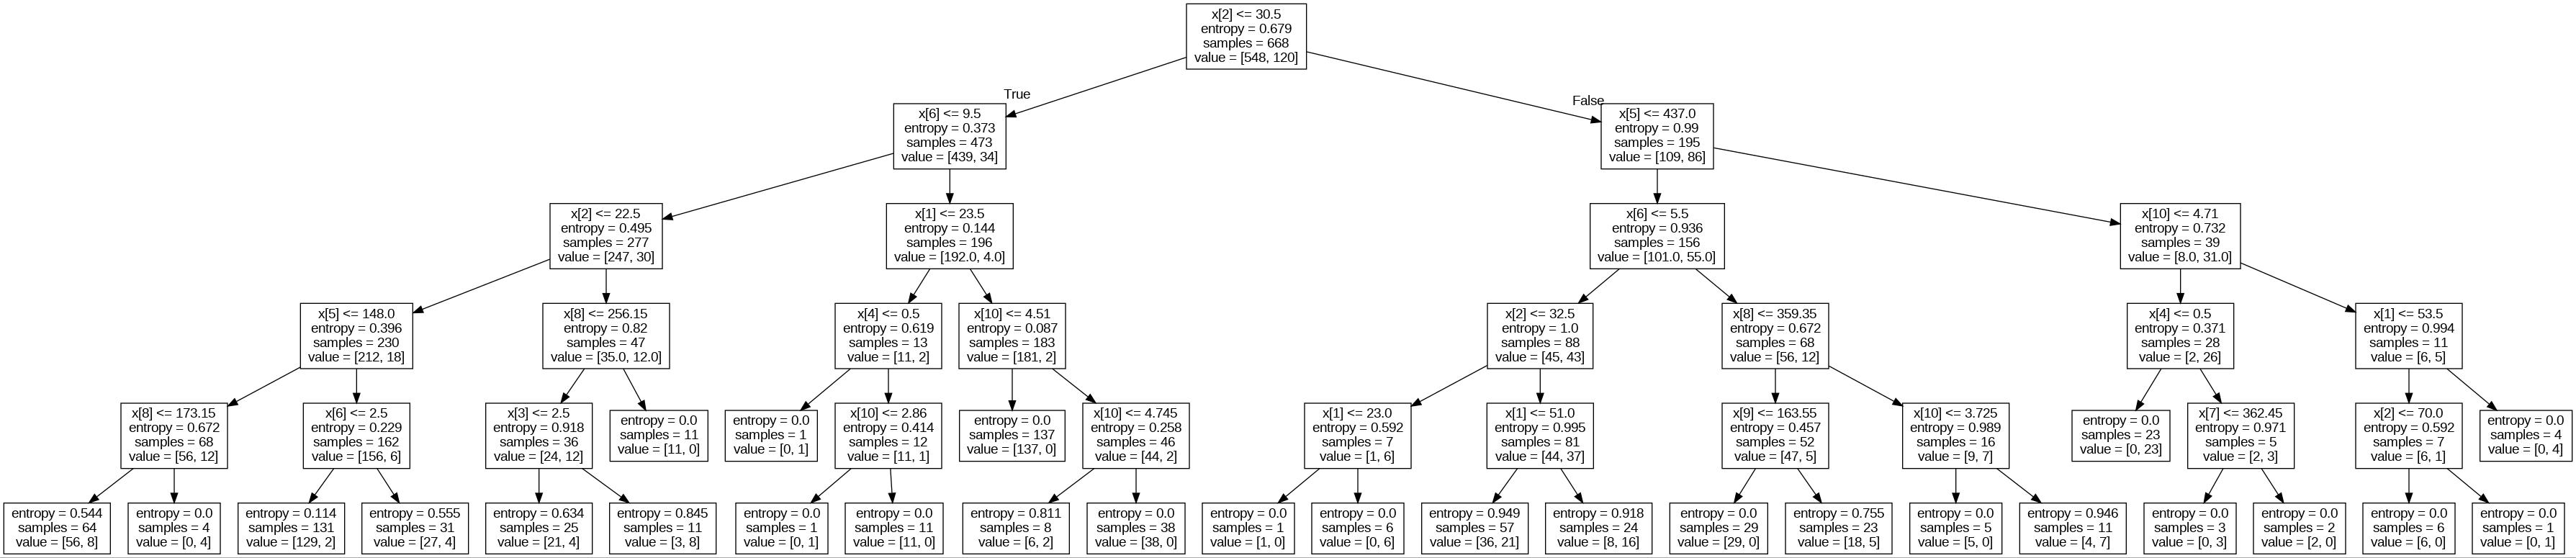

In [ ]:
from PIL import Image
Image.open('/content/user.jpg')

## 4. Random Forest Modeling

In [ ]:
# 1. Grid searching
param_grid = {
    'criterion':['entropy','gini'],# metric
    'max_depth':[5, 6, 7, 8],    # depth
    'n_estimators':[11,13,15],  # number of trees
    'max_features':[0.3,0.4,0.5], # weight of each tree
    'min_samples_split':[4,8,12,16]  # sample of each leaf
}

In [ ]:
import sklearn.ensemble as ensemble # Ensemble learning

In [ ]:
# 2. Random Forest
rfc = ensemble.RandomForestClassifier()
rfc_cv = GridSearchCV(estimator=rfc, param_grid=param_grid,
                      scoring='roc_auc', cv=4)
rfc_cv.fit(X_train, y_train)

GridSearchCV(cv=4, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['entropy', 'gini'],
                         'max_depth': [5, 6, 7, 8],
                         'max_features': [0.3, 0.4, 0.5],
                         'min_samples_split': [4, 8, 12, 16],
                         'n_estimators': [11, 13, 15]},
             scoring='roc_auc')

In [ ]:
# 3. RFC Predict
predict_test = rfc_cv.predict(X_test)
print('Accuracy of RFC')
print(metrics.classification_report(predict_test, y_test))

Accuracy of RFC
              precision    recall  f1-score   support

           0       0.99      0.88      0.93       402
           1       0.45      0.89      0.60        44

    accuracy                           0.88       446
   macro avg       0.72      0.88      0.77       446
weighted avg       0.93      0.88      0.90       446



In [ ]:
# 4. AUC
print('AUC of RFC')
fpr_test, tpr_test, th_test = metrics.roc_curve(predict_test, y_test) # roc Cruve
print('AUC = %.4f' %metrics.auc(fpr_test, tpr_test))

AUC of RFC
AUC = 0.8847


In [ ]:
# 5. Parameters
rfc_cv.best_params_

{'criterion': 'entropy',
 'max_depth': 8,
 'max_features': 0.4,
 'min_samples_split': 4,
 'n_estimators': 11}

In [ ]:
# 6. Fine turning
param_grid = {
    'criterion':['entropy','gini'],
    'max_depth':[7, 8, 10, 12], # Drop 5，6
    'n_estimators':[11, 13, 15, 17, 19],
    'max_features':[0.4, 0.5, 0.6, 0.7],
    'min_samples_split':[2, 3, 4, 8, 12, 16]
}
# 7. Repeat
rfc_cv = GridSearchCV(estimator=rfc, param_grid=param_grid,
                      scoring='roc_auc', cv=4)
rfc_cv.fit(X_train, y_train)
# 8. Predict
predict_test = rfc_cv.predict(X_test)
print('Accuracy')
print(metrics.classification_report(predict_test, y_test))
print('AUC')
fpr_test, tpr_test, th_test = metrics.roc_curve(predict_test, y_test) # roc Cruve
print('AUC = %.4f' %metrics.auc(fpr_test, tpr_test))

Accuracy
              precision    recall  f1-score   support

           0       0.99      0.90      0.94       395
           1       0.53      0.90      0.67        51

    accuracy                           0.90       446
   macro avg       0.76      0.90      0.81       446
weighted avg       0.93      0.90      0.91       446

AUC
AUC = 0.9003


In [ ]:
# 8. Best parameters
rfc_cv.best_params_

{'criterion': 'gini',
 'max_depth': 12,
 'max_features': 0.6,
 'min_samples_split': 2,
 'n_estimators': 19}

# Results
## Model Performance:
  The fine-tuned Random Forest model (second round) outperforms the initial model:

- **Accuracy:** Improved from 88% to 90%.

- **AUC:** Improved from 0.8847 to 0.9003.

- **Churn Prediction:** Higher precision (0.53 vs. 0.45) and F1-score (0.67 vs. 0.60) for churn class.

The model is highly effective at identifying non-churn customers (precision = 0.99) and has strong recall for churn customers (0.90).

## Key Features (inferred from Random Forest):

- Features like TENURE, ARPB_3M, DAY_MOU, AFTERNOON_MOU, NIGHT_MOU, AVG_CALL_LENGTH, AUTOPAY, and BROADBAND likely play significant roles in predicting churn, as Random Forest uses all features unless specified otherwise.


# Recommendations
1. **Target Churn-Prone Customers:** Use the model to identify high-risk customers (predicted churn = 1) and offer retention incentives, such as discounts or personalized plans.
2. **Focus on Key Features:**
 - **Low Tenure:** Customers with shorter tenure may be more likely to churn; engage them early with loyalty programs.
 - **Billing (ARPB_3M):** High or fluctuating billing amounts could indicate dissatisfaction; review pricing strategies.
 - **Usage Patterns:** Low DAY_MOU or AFTERNOON_MOU may signal reduced engagement; promote additional services like broadband.
3. **Promote Autopay:** Encourage autopay enrollment, as it may correlate with lower churn rates.
4. **Broadband Upsell:** Customers without broadband (BROADBAND=0) may be at higher risk; offer bundled broadband packages.